In [1]:
%pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [2]:
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from PIL import Image, ImageOps
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from google.colab import drive
from IPython.display import display
from tqdm.auto import tqdm

import open_clip

#! Reproducibility and device
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#! Existing Google Drive structure
drive.mount("/content/drive")
TASK_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid/task1")
DATA_PATH = TASK_ROOT / "data/stl10_labeled.npz"
FEATURE_DIR = TASK_ROOT / "results/features"
HEAD_DIR = TASK_ROOT / "models/heads"
BASELINE_DIR = TASK_ROOT / "results/clean_baseline"
COLOR_DIR = TASK_ROOT / "results/color_bias"
IMAGE_DIR = COLOR_DIR / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["resnet50", "vit_b16", "clip_b32"]
MODEL_ORDER = MODEL_NAMES + ["clip_zero_shot"]
CONDITIONS = ["grayscale", "hue90"]
FEATURE_DIMS = {"resnet50": 2048, "vit_b16": 768, "clip_b32": 512}
HUE_FACTOR = 0.25  #! 0.25 of a full hue revolution = +90 degrees

#! Load exactly the Part A/C test subset
with np.load(DATA_PATH, allow_pickle=False) as data:
    test_images = data["test_images"]
    test_labels = data["test_labels"].astype(np.int64)
    test_indices = data["test_indices"].astype(np.int64)
    CLASS_NAMES = data["class_names"].tolist()

baseline_summary = pd.read_csv(BASELINE_DIR / "summary.csv")
saved_ids = np.load(BASELINE_DIR / "clean_image_ids.npy", allow_pickle=False)

if len(test_indices) != 500 or not np.array_equal(saved_ids, test_indices):
    raise ValueError("Test image IDs do not match Part C.")

required = ([HEAD_DIR / f"{name}_head.pt" for name in MODEL_NAMES]
            + [BASELINE_DIR / f"{name}_clean_predictions.npz" for name in MODEL_ORDER]
            + [FEATURE_DIR / "clip_zeroshot.pt"])
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Part B/C files missing: {missing}")

#! Save the experimental choice and hypothesis before evaluation
experiment = {
    "seed": SEED,
    "dataset": "STL-10",
    "test_image_ids_file": str(BASELINE_DIR / "clean_image_ids.npy"),
    "n_images": 500,
    "conditions": {
        "grayscale": "RGB -> luminance grayscale -> RGB; preserves geometry",
        "hue90": "fixed +90 degree HSV hue rotation; geometry stays fixed"
    },
    "hue_factor": HUE_FACTOR,
    "hypothesis": "Removing or changing hue may reduce accuracy and alter predictions; the extent will differ by model, without a predetermined ranking.",
    "primary_metrics": ["accuracy_change_percentage_points", "prediction_consistency"],
    "additional_metrics": ["accuracy", "macro_f1", "mean_max_confidence"],
    "preprocessing": "PIL bicubic resize to RGB 224x224; intervene before backbone-specific normalization"
}
config_path = COLOR_DIR / "experiment_config.json"
if config_path.exists():
    with open(config_path) as f:
        if json.load(f) != experiment:
            raise ValueError("Existing experiment settings differ. Inspect before overwriting.")
else:
    with open(config_path, "w") as f:
        json.dump(experiment, f, indent=2)

print("Device:", DEVICE)
print("Selected images:", len(test_indices))
print("Conditions:", CONDITIONS)
print("Results folder:", COLOR_DIR)

Mounted at /content/drive
Device: cuda
Selected images: 500
Conditions: ['grayscale', 'hue90']
Results folder: /content/drive/MyDrive/pa1-beyond-iid/task1/results/color_bias


## Cell 2 — Generate and cache the **same** two transformed image sets for every model
Start from the same PIL 224×224 bicubic image used in Part B. Apply grayscale or fixed hue adjustment **before normalization**, and store each resulting RGB image as `uint8` to avoid recomputation. Filenames, IDs and labels are saved together.

In [3]:
#! Generate only missing image caches
missing_conditions = [name for name in CONDITIONS
                      if not (IMAGE_DIR / f"{name}_images.pt").is_file()]
image_caches = {
    name: torch.empty((500, 3, 224, 224), dtype=torch.uint8)
    for name in missing_conditions
}

for i in tqdm(range(len(test_images)), desc="Preparing color interventions", disable=not missing_conditions):
    if not missing_conditions:
        break

    image = Image.fromarray(np.transpose(test_images[i], (1, 2, 0))).convert("RGB")
    image = TF.resize(image, [224, 224], interpolation=InterpolationMode.BICUBIC)

    for condition in missing_conditions:
        if condition == "grayscale":
            transformed = ImageOps.grayscale(image).convert("RGB")
        else:
            transformed = TF.adjust_hue(image, hue_factor=HUE_FACTOR)

        rgb = np.asarray(transformed, dtype=np.uint8).copy()
        image_caches[condition][i] = torch.from_numpy(rgb).permute(2, 0, 1)

#! Persist images and verify any existing cache matches the experiment
for condition in CONDITIONS:
    path = IMAGE_DIR / f"{condition}_images.pt"
    if condition in image_caches:
        torch.save({
            "images": image_caches[condition],
            "indices": torch.from_numpy(test_indices.copy()),
            "labels": torch.from_numpy(test_labels.copy()),
            "seed": SEED,
            "condition": condition,
            "hue_factor": HUE_FACTOR
        }, path)

    cache = torch.load(path, map_location="cpu", weights_only=True)
    if (cache["images"].shape != (500, 3, 224, 224)
        or cache["images"].dtype != torch.uint8
        or not np.array_equal(cache["indices"].numpy(), test_indices)
        or not np.array_equal(cache["labels"].numpy(), test_labels)
        or cache["condition"] != condition
        or cache["hue_factor"] != HUE_FACTOR):
        raise ValueError(f"Incompatible image cache: {path}")
    print("Saved/verified:", path.name)

del image_caches
print("Both common image interventions are ready.")

Preparing color interventions:   0%|          | 0/500 [00:00<?, ?it/s]

Saved/verified: grayscale_images.pt
Saved/verified: hue90_images.pt
Both common image interventions are ready.


## Cell 3 — Save visual examples for inspection
Show four predefined classes side by side. Compare originals with grayscale and hue-rotated images **before evaluating models**; the image IDs are saved with the figure.

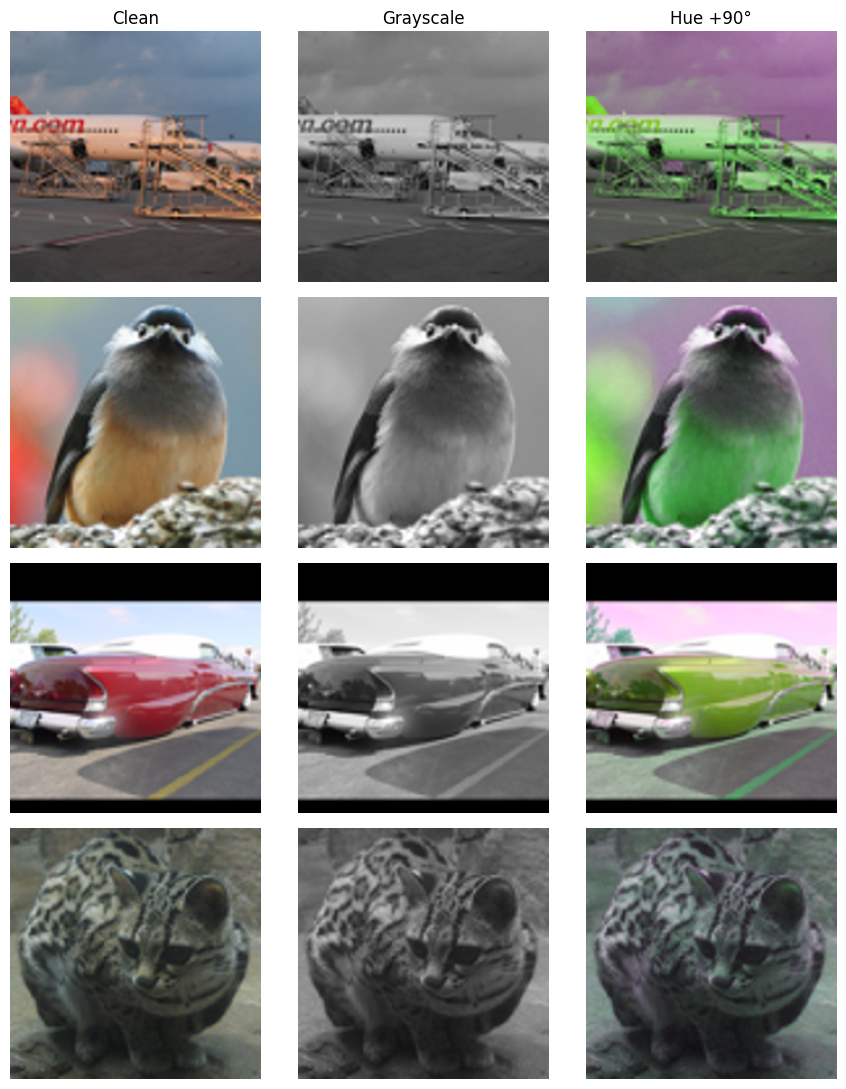

Saved examples and image IDs.


In [4]:
import matplotlib.pyplot as plt

#! Select the first occurrence of each of four classes, without model predictions
positions = [int(np.flatnonzero(test_labels == label)[0]) for label in range(4)]
gray = torch.load(IMAGE_DIR / "grayscale_images.pt", map_location="cpu", weights_only=True)["images"]
hue = torch.load(IMAGE_DIR / "hue90_images.pt", map_location="cpu", weights_only=True)["images"]

fig, axes = plt.subplots(len(positions), 3, figsize=(9, 11))
for row, pos in enumerate(positions):
    original = Image.fromarray(np.transpose(test_images[pos], (1, 2, 0))).convert("RGB")
    original = TF.resize(original, [224, 224], interpolation=InterpolationMode.BICUBIC)
    displays = [np.asarray(original), gray[pos].permute(1, 2, 0).numpy(),
                hue[pos].permute(1, 2, 0).numpy()]
    for col, image in enumerate(displays):
        axes[row, col].imshow(image)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(["Clean", "Grayscale", "Hue +90°"][col])
    axes[row, 0].set_ylabel(CLASS_NAMES[int(test_labels[pos])])

fig.tight_layout()
fig.savefig(COLOR_DIR / "color_examples.png", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame({"image_id": test_indices[positions],
              "true_label": test_labels[positions],
              "true_class": [CLASS_NAMES[test_labels[p]] for p in positions]
              }).to_csv(COLOR_DIR / "visual_example_ids.csv", index=False)
print("Saved examples and image IDs.")
del gray, hue

## Cell 4 — Load each frozen backbone **once** and save transformed features
This is the computationally expensive part. Backbones and normalization match your Part B code. No heads are retrained; both transformations are processed with each loaded backbone, and all features are cached for Part F representation analysis.

In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
FEATURE_BATCH_SIZE = 16

class SavedImageDataset(Dataset):
    def __init__(self, saved):
        self.images = saved["images"]
        self.labels = saved["labels"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        #! Equivalent to ToTensor on the cached RGB uint8 PIL image
        return self.images[idx].float().div(255.0), self.labels[idx].long()


def load_backbone(name):
    if name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Identity()
    elif name == "vit_b16":
        model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        model.heads = nn.Identity()
    elif name == "clip_b32":
        model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    else:
        raise ValueError(f"Unknown backbone: {name}")

    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.to(DEVICE).eval()


@torch.inference_mode()
def extract_transformed_features(model, images_file, model_name):
    saved = torch.load(images_file, map_location="cpu", weights_only=True)
    loader = DataLoader(SavedImageDataset(saved), batch_size=FEATURE_BATCH_SIZE,
                        shuffle=False, num_workers=0, pin_memory=(DEVICE.type == "cuda"))

    mean_values, std_values = ((CLIP_MEAN, CLIP_STD) if model_name == "clip_b32"
                               else (IMAGENET_MEAN, IMAGENET_STD))
    mean = torch.tensor(mean_values, device=DEVICE).view(1, 3, 1, 1)
    std = torch.tensor(std_values, device=DEVICE).view(1, 3, 1, 1)
    features, labels = [], []

    for images, targets in tqdm(loader, desc=f"{model_name}: {saved['condition']}"):
        images = images.to(DEVICE, non_blocking=True)
        images = (images - mean) / std
        if model_name == "clip_b32":
            output = F.normalize(model.encode_image(images).float(), p=2, dim=-1)
        else:
            output = model(images).float()
        features.append(output.cpu())
        labels.append(targets.cpu())

    return torch.cat(features), torch.cat(labels)


#! Cache features without overwriting valid prior computation
for model_name in MODEL_NAMES:
    needed = []
    for condition in CONDITIONS:
        path = FEATURE_DIR / f"{model_name}_{condition}.pt"
        if path.is_file():
            saved = torch.load(path, map_location="cpu", weights_only=True)
            if (saved["features"].shape != (500, FEATURE_DIMS[model_name])
                or not np.array_equal(saved["indices"].numpy(), test_indices)
                or not np.array_equal(saved["labels"].numpy(), test_labels)
                or saved["condition"] != condition or saved["seed"] != SEED):
                raise ValueError(f"Incompatible features: {path}")
            print("Reusing:", path.name)
        else:
            needed.append(condition)

    if not needed:
        continue

    print("Loading pretrained backbone:", model_name)
    backbone = load_backbone(model_name)
    for condition in needed:
        features, labels = extract_transformed_features(
            backbone, IMAGE_DIR / f"{condition}_images.pt", model_name
        )
        if features.shape != (500, FEATURE_DIMS[model_name]):
            raise ValueError(f"Unexpected feature dimensions: {model_name}, {condition}")
        torch.save({
            "features": features.float(),
            "labels": labels.long(),
            "indices": torch.from_numpy(test_indices.copy()),
            "condition": condition,
            "seed": SEED
        }, FEATURE_DIR / f"{model_name}_{condition}.pt")
        print("Saved:", f"{model_name}_{condition}.pt")
        del features, labels

    del backbone
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("All six transformed-feature files are ready.")

Loading pretrained backbone: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 40.4MB/s]


resnet50: grayscale:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: resnet50_grayscale.pt


resnet50: hue90:   0%|          | 0/32 [00:00<?, ?it/s]

...

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


clip_b32: grayscale:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: clip_b32_grayscale.pt


clip_b32: hue90:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: clip_b32_hue90.pt
All six transformed-feature files are ready.


## Cell 5 — Evaluate four configurations against their **own paired clean predictions**
Load the best saved linear heads and CLIP prompt embeddings. Calculate accuracy, macro-F1, mean maximum confidence, percentage-point accuracy change, and prediction consistency. Save numerical results *and* individual per-image predictions.

In [6]:
summary_rows = []
prediction_rows = []
zero_shot = torch.load(FEATURE_DIR / "clip_zeroshot.pt", map_location="cpu", weights_only=True)
text_features = zero_shot["text_features"].float()
logit_scale = float(zero_shot["logit_scale"])  #! Already exp(logit_scale) from Part B


def save_evaluation(model_name, condition, logits):
    clean_path = BASELINE_DIR / f"{model_name}_clean_predictions.npz"
    with np.load(clean_path, allow_pickle=False) as clean:
        clean_ids = clean["image_ids"]
        clean_labels = clean["y_true"]
        clean_pred = clean["y_pred"]

    if (not np.array_equal(clean_ids, test_indices)
        or not np.array_equal(clean_labels, test_labels)):
        raise ValueError(f"Clean-image order mismatch: {model_name}")

    with torch.inference_mode():
        probabilities = torch.softmax(logits.float(), dim=1)
        confidence, predicted = probabilities.max(dim=1)

    y_pred = predicted.cpu().numpy().astype(np.int64)
    confidence_np = confidence.cpu().numpy()
    clean_acc = float(accuracy_score(test_labels, clean_pred))
    accuracy = float(accuracy_score(test_labels, y_pred))
    consistency = float(np.mean(y_pred == clean_pred))
    correct = y_pred == test_labels

    np.savez_compressed(
        COLOR_DIR / f"{model_name}_{condition}_predictions.npz",
        image_ids=test_indices, y_true=test_labels, y_pred=y_pred,
        clean_y_pred=clean_pred, logits=logits.cpu().numpy(),
        probabilities=probabilities.cpu().numpy(), max_confidence=confidence_np,
        correct=correct, prediction_changed=(y_pred != clean_pred)
    )

    pd.DataFrame(confusion_matrix(test_labels, y_pred, labels=list(range(10))),
                 index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
                     COLOR_DIR / f"{model_name}_{condition}_confusion.csv",
                     index_label="true/predicted"
                 )

    summary_rows.append({
        "model": model_name, "condition": condition, "n_images": len(test_labels),
        "clean_accuracy": clean_acc, "accuracy": accuracy,
        "accuracy_change_pp": 100 * (accuracy - clean_acc),
        "prediction_consistency": consistency,
        "n_changed": int(np.sum(y_pred != clean_pred)),
        "n_correct": int(correct.sum()),
        "macro_f1": float(f1_score(test_labels, y_pred, labels=list(range(10)),
                                   average="macro", zero_division=0)),
        "mean_max_confidence": float(confidence_np.mean()), "seed": SEED
    })

    prediction_rows.extend({
        "image_id": int(test_indices[i]), "model": model_name,
        "condition": condition, "true_label": int(test_labels[i]),
        "clean_prediction": int(clean_pred[i]), "new_prediction": int(y_pred[i]),
        "correct": bool(correct[i]), "prediction_changed": bool(y_pred[i] != clean_pred[i]),
        "max_confidence": float(confidence_np[i])
    } for i in range(len(test_labels)))

    print(f"{model_name} / {condition}: accuracy={accuracy:.4f}, "
          f"change={100 * (accuracy-clean_acc):+.2f} pp, consistency={consistency:.4f}")


#! Trained linear classifiers, using fixed best checkpoints from Part B
for model_name in MODEL_NAMES:
    checkpoint = torch.load(HEAD_DIR / f"{model_name}_head.pt",
                            map_location="cpu", weights_only=True)
    head = nn.Linear(checkpoint["in_features"], checkpoint["num_classes"])
    head.load_state_dict(checkpoint["head_state_dict"])
    head.eval()

    for condition in CONDITIONS:
        saved = torch.load(FEATURE_DIR / f"{model_name}_{condition}.pt",
                           map_location="cpu", weights_only=True)
        if not np.array_equal(saved["indices"].numpy(), test_indices):
            raise ValueError(f"Image IDs mismatch: {model_name}/{condition}")
        with torch.inference_mode():
            logits = head(saved["features"].float())
        save_evaluation(model_name, condition, logits)

        #! CLIP zero-shot uses the same CLIP image features, without a trained head
        if model_name == "clip_b32":
            with torch.inference_mode():
                zero_logits = logit_scale * (saved["features"].float() @ text_features.T)
            save_evaluation("clip_zero_shot", condition, zero_logits)
    del head

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(COLOR_DIR / "summary.csv", index=False)
pd.DataFrame(prediction_rows).to_csv(COLOR_DIR / "predictions.csv", index=False)
with open(COLOR_DIR / "summary.json", "w") as f:
    json.dump({"seed": SEED, "results": summary_rows}, f, indent=2)

print("\nCOLOR BIAS RESULTS")
display(summary_df.round(4))

resnet50 / grayscale: accuracy=0.9580, change=-1.80 pp, consistency=0.9640
resnet50 / hue90: accuracy=0.9300, change=-4.60 pp, consistency=0.9420
vit_b16 / grayscale: accuracy=0.9520, change=-2.20 pp, consistency=0.9520
vit_b16 / hue90: accuracy=0.9440, change=-3.00 pp, consistency=0.9440
clip_b32 / grayscale: accuracy=0.9560, change=-2.40 pp, consistency=0.9540
clip_zero_shot / grayscale: accuracy=0.9420, change=-2.60 pp, consistency=0.9520
clip_b32 / hue90: accuracy=0.9460, change=-3.40 pp, consistency=0.9420
clip_zero_shot / hue90: accuracy=0.9280, change=-4.00 pp, consistency=0.9340

COLOR BIAS RESULTS


,model,condition,n_images,clean_accuracy,accuracy,accuracy_change_pp,prediction_consistency,n_changed,n_correct,macro_f1,mean_max_confidence,seed
0,resnet50,grayscale,500,0.976,0.958,-1.8,0.964,18,479,0.9578,0.9317,6304
1,resnet50,hue90,500,0.976,0.930,-4.6,0.942,29,465,0.9298,0.9148,6304
2,vit_b16,grayscale,500,0.974,0.952,-2.2,0.952,24,476,0.9520,0.9644,6304
3,vit_b16,hue90,500,0.974,0.944,-3.0,0.944,28,472,0.9440,0.9406,6304
4,clip_b32,grayscale,500,0.980,0.956,-2.4,0.954,23,478,0.9556,0.2258,6304
5,clip_zero_shot,grayscale,500,0.968,0.942,-2.6,0.952,24,471,0.9411,0.9274,6304
6,clip_b32,hue90,500,0.980,0.946,-3.4,0.942,29,473,0.9457,0.2166,6304
7,clip_zero_shot,hue90,500,0.968,0.928,-4.0,0.934,33,464,0.9264,0.9193,6304


## Cell 6 — Save report figures
Plot accuracy for the three conditions (clean baseline, grayscale, hue +90°) and prediction consistency against the paired clean predictions. Save both figures at 300 dpi.

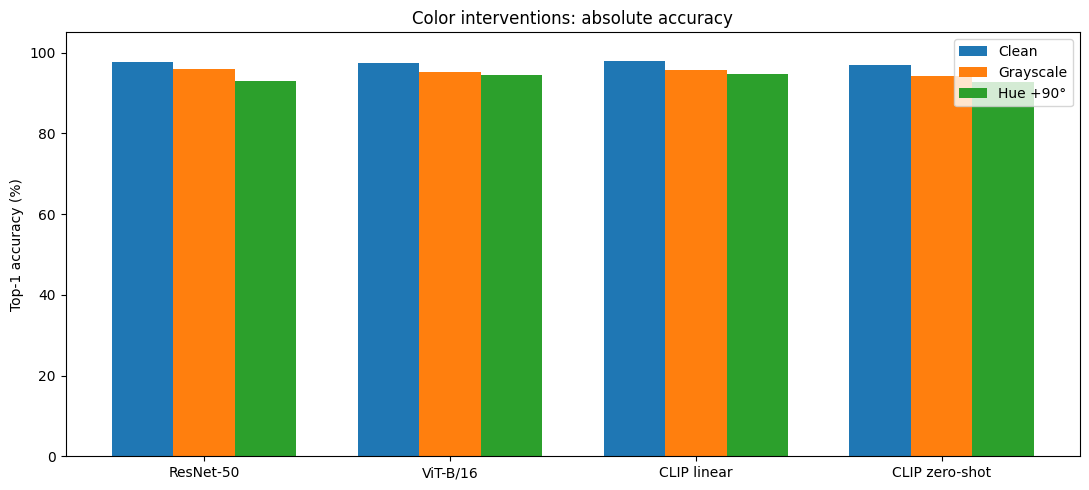

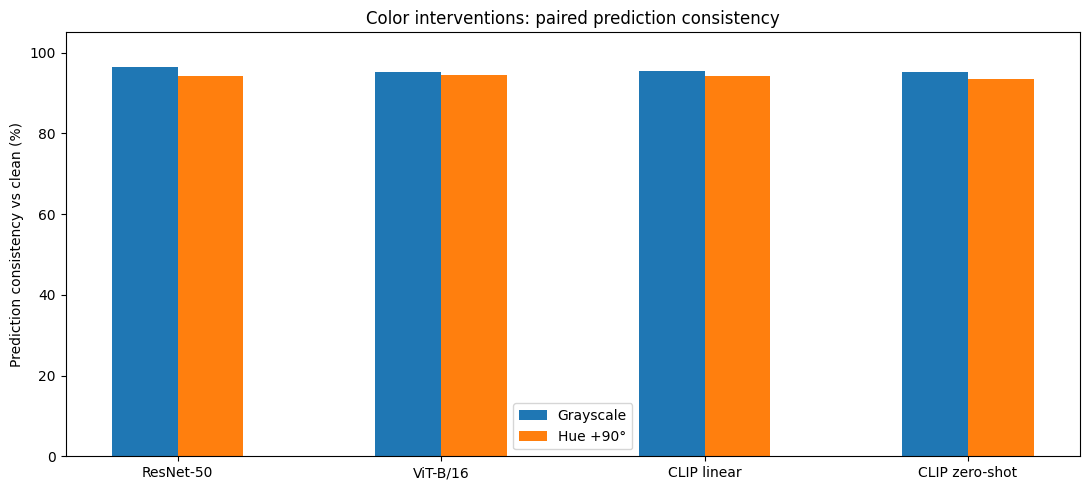

Saved both report figures.


In [7]:
#! Figure 1: absolute clean and transformed accuracy
labels = ["ResNet-50", "ViT-B/16", "CLIP linear", "CLIP zero-shot"]
x = np.arange(len(MODEL_ORDER))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

clean_acc = [summary_df.loc[summary_df.model == m, "clean_accuracy"].iloc[0]
             for m in MODEL_ORDER]
ax.bar(x - width, np.array(clean_acc) * 100, width, label="Clean")
for offset, condition, label in [(0, "grayscale", "Grayscale"),
                                  (width, "hue90", "Hue +90°")]:
    vals = [summary_df.loc[(summary_df.model == m) & (summary_df.condition == condition),
                           "accuracy"].iloc[0] for m in MODEL_ORDER]
    ax.bar(x + offset, np.array(vals) * 100, width, label=label)

ax.set_xticks(x, labels)
ax.set_ylim(0, 105)
ax.set_ylabel("Top-1 accuracy (%)")
ax.set_title("Color interventions: absolute accuracy")
ax.legend()
fig.tight_layout()
fig.savefig(COLOR_DIR / "color_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

#! Figure 2: paired prediction consistency
fig, ax = plt.subplots(figsize=(11, 5))
for offset, condition, label in [(-width / 2, "grayscale", "Grayscale"),
                                  (width / 2, "hue90", "Hue +90°")]:
    vals = [summary_df.loc[(summary_df.model == m) & (summary_df.condition == condition),
                           "prediction_consistency"].iloc[0] for m in MODEL_ORDER]
    ax.bar(x + offset, np.array(vals) * 100, width, label=label)

ax.set_xticks(x, labels)
ax.set_ylim(0, 105)
ax.set_ylabel("Prediction consistency vs clean (%)")
ax.set_title("Color interventions: paired prediction consistency")
ax.legend()
fig.tight_layout()
fig.savefig(COLOR_DIR / "color_consistency.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved both report figures.")

## Cell 7 — Lightweight final verification
Reload saved aggregate and individual results from Drive. Check file presence and alignment; do not generate any missing files here. After it passes, this runtime can be disconnected.

In [8]:
summary = pd.read_csv(COLOR_DIR / "summary.csv")
predictions = pd.read_csv(COLOR_DIR / "predictions.csv")
required_files = ["experiment_config.json", "summary.csv", "summary.json",
                  "predictions.csv", "color_examples.png", "visual_example_ids.csv",
                  "color_accuracy.png", "color_consistency.png"]

for condition in CONDITIONS:
    required_files.append(f"images/{condition}_images.pt")
    for model_name in MODEL_ORDER:
        required_files.extend([f"{model_name}_{condition}_predictions.npz",
                               f"{model_name}_{condition}_confusion.csv"])
    for model_name in MODEL_NAMES:
        path = FEATURE_DIR / f"{model_name}_{condition}.pt"
        if not path.is_file():
            raise FileNotFoundError(f"Missing transformed features: {path}")

missing = [name for name in required_files if not (COLOR_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Missing Part D files: {missing}")

if len(summary) != 8 or len(predictions) != 4000:
    raise ValueError("Expected 8 model-condition evaluations and 4000 per-image records.")

for condition in CONDITIONS:
    for model_name in MODEL_ORDER:
        with np.load(COLOR_DIR / f"{model_name}_{condition}_predictions.npz",
                     allow_pickle=False) as record:
            if (not np.array_equal(record["image_ids"], test_indices)
                or len(record["y_pred"]) != 500):
                raise ValueError(f"Mismatch: {model_name}/{condition}")
        print("Verified:", model_name, condition)

print("\nPART D COMPLETE — results saved to:", COLOR_DIR)
display(summary.round(4))

Verified: resnet50 grayscale
Verified: vit_b16 grayscale
Verified: clip_b32 grayscale
Verified: clip_zero_shot grayscale
Verified: resnet50 hue90
Verified: vit_b16 hue90
Verified: clip_b32 hue90
Verified: clip_zero_shot hue90

PART D COMPLETE — results saved to: /content/drive/MyDrive/pa1-beyond-iid/task1/results/color_bias


,model,condition,n_images,clean_accuracy,accuracy,accuracy_change_pp,prediction_consistency,n_changed,n_correct,macro_f1,mean_max_confidence,seed
0,resnet50,grayscale,500,0.976,0.958,-1.8,0.964,18,479,0.9578,0.9317,6304
1,resnet50,hue90,500,0.976,0.930,-4.6,0.942,29,465,0.9298,0.9148,6304
2,vit_b16,grayscale,500,0.974,0.952,-2.2,0.952,24,476,0.9520,0.9644,6304
3,vit_b16,hue90,500,0.974,0.944,-3.0,0.944,28,472,0.9440,0.9406,6304
4,clip_b32,grayscale,500,0.980,0.956,-2.4,0.954,23,478,0.9556,0.2258,6304
5,clip_zero_shot,grayscale,500,0.968,0.942,-2.6,0.952,24,471,0.9411,0.9274,6304
6,clip_b32,hue90,500,0.980,0.946,-3.4,0.942,29,473,0.9457,0.2166,6304
7,clip_zero_shot,hue90,500,0.968,0.928,-4.0,0.934,33,464,0.9264,0.9193,6304
